# Model-specific feature-group selection

This notebook is a **development analysis**, not an untouched outer-test evaluation. It compares predefined feature groups through chronological validation and never uses closing-market performance to select features.

Workflow:

1. Add feature groups cumulatively for each model family.
2. Select the simplest set within a small log-loss tolerance of that model's best set.
3. Remove one whole group at a time from the selected set as a stability diagnostic.
4. Save a separate removal chart for every model.

Because Scotland has already been inspected repeatedly, selections made here must be frozen and confirmed on another league or a future season.

In [1]:
from __future__ import annotations

import re
import sys
from collections import OrderedDict
from dataclasses import dataclass
from pathlib import Path
from typing import Callable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path(r"C:\Users\skous\Super-League-odds-research")
SCOTLAND_RESEARCH = REPO_ROOT / "scotland_research"
assert SCOTLAND_RESEARCH.exists(), SCOTLAND_RESEARCH
sys.path.insert(0, str(SCOTLAND_RESEARCH))

from build_match_features import (
    ADJUSTED_MEAN_FEATURES,
    BASE_SUM_FEATURES,
    DISTRIBUTION_FEATURES,
    LINEUP_FEATURES,
    POSITION_FEATURES,
    RECENCY_MEAN_FEATURES,
    TEAM_STRENGTH_FEATURES,
)
from constants import CLASS_ORDER
from data.load_model_dataset import load_dataset
from evaluation.metrics import score_predictions
from models.dixon_coles_player_form import DixonColesPlayerFormModel
from models.expanded_player_form_lightgbm import ExpandedPlayerFormLightGBMModel
from models.market_plus_player_form import MarketPlusPlayerFormModel
from models.player_form import PlayerFormModel
from models.player_form_lightgbm import PlayerFormLightGBMModel

In [2]:
MODEL_DATASET = REPO_ROOT / "data" / "processed" / "scotland" / "scotland_model_dataset.csv"
OUTPUT_DIR = REPO_ROOT / "artifacts" / "scotland_feature_group_selection"
IMAGE_DIR = SCOTLAND_RESEARCH / "visuals" / "feature_removal_help"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

# If several feature sets are effectively tied, prefer the smaller set.
SELECTION_TOLERANCE = 0.005
MODEL_DATASET, OUTPUT_DIR, IMAGE_DIR

(WindowsPath('C:/Users/skous/Super-League-odds-research/data/processed/scotland/scotland_model_dataset.csv'),
 WindowsPath('C:/Users/skous/Super-League-odds-research/artifacts/scotland_feature_group_selection'),
 WindowsPath('C:/Users/skous/Super-League-odds-research/scotland_research/visuals/feature_removal_help'))

## Feature groups

Groups are selected instead of individual columns because correlated features can substitute for one another. Single-feature removal would therefore give unstable and misleading importance estimates.

In [3]:
def unique(values: list[str]) -> list[str]:
    return list(dict.fromkeys(values))

FEATURE_GROUPS = OrderedDict(
    [
        (
            "core",
            unique(
                [
                    *BASE_SUM_FEATURES,
                    "rating_mean_5",
                    "starters_without_history",
                    "starters_without_full_window",
                ]
            ),
        ),
        ("team_strength", list(TEAM_STRENGTH_FEATURES)),
        ("opponent_adjusted_form", list(ADJUSTED_MEAN_FEATURES)),
        ("lineup_continuity", list(LINEUP_FEATURES)),
        ("position_and_distribution", unique(POSITION_FEATURES + DISTRIBUTION_FEATURES)),
        ("recency", list(RECENCY_MEAN_FEATURES)),
    ]
)

CANDIDATE_FEATURE_SETS: OrderedDict[str, list[str]] = OrderedDict()
cumulative: list[str] = []
labels: list[str] = []
for group_name, group_features in FEATURE_GROUPS.items():
    cumulative = unique(cumulative + group_features)
    labels.append(group_name)
    CANDIDATE_FEATURE_SETS[" + ".join(labels)] = cumulative.copy()

pd.DataFrame(
    [
        {"feature_set": name, "base_feature_count": len(features)}
        for name, features in CANDIDATE_FEATURE_SETS.items()
    ]
)

,feature_set,base_feature_count
0,core,7
1,core + team_strength,15
2,core + team_strength + opponent_adjusted_form,39
3,core + team_strength + opponent_adjusted_form ...,46
4,core + team_strength + opponent_adjusted_form ...,66
5,core + team_strength + opponent_adjusted_form ...,83


## Chronological development folds

Every validation season is predicted only from earlier seasons. These are now development folds because their results have already been viewed. They must not be described as untouched confirmation after feature selection.

In [4]:
dataset = load_dataset(MODEL_DATASET)

def ordered_seasons(frame: pd.DataFrame) -> list[str]:
    return (
        frame.groupby("season")["_match_datetime"]
        .min()
        .sort_values()
        .index.astype(str)
        .tolist()
    )

def development_folds(frame: pd.DataFrame):
    seasons = ordered_seasons(frame)
    for validation_index in range(1, len(seasons)):
        train_seasons = seasons[:validation_index]
        validation_season = seasons[validation_index]
        train = frame[frame["season"].isin(train_seasons)].copy()
        validation = frame[frame["season"].eq(validation_season)].copy()

        if set(train["result_3way"]) != set(CLASS_ORDER):
            raise ValueError(f"Training data before {validation_season} lacks an outcome class")
        yield train, validation, validation_season

[(season, len(train), len(validation)) for train, validation, season in development_folds(dataset)]

C:\Users\skous\Super-League-odds-research\scotland_research\data\load_model_dataset.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame["_match_datetime"] = pd.to_datetime(
C:\Users\skous\Super-League-odds-research\scotland_research\data\load_model_dataset.py:66: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame["market_log_home_vs_draw"] = np.log(
C:\Users\skous\Super-League-odds-research\scotland_research\data\load_model_dataset.py:69: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of 

[('2021-22', 228, 228),
 ('2022-23', 456, 226),
 ('2023-24', 682, 212),
 ('2024-25', 894, 227)]

## Model families

Difference models receive home-minus-away columns. The expanded LightGBM receives separate home and away columns. Each model is compared only with itself across feature sets. Hyperparameter tuning should be rerun after a feature set is frozen.

In [5]:
@dataclass(frozen=True)
class ModelSpec:
    name: str
    label: str
    representation: str
    factory: Callable[[list[str], str], object]

def representation_columns(base_features: list[str], representation: str) -> list[str]:
    if representation == "diff":
        return [f"diff_{feature}" for feature in base_features]
    if representation == "expanded":
        return [f"{side}_{feature}" for side in ("home", "away") for feature in base_features]
    raise ValueError(f"Unknown representation: {representation}")

MODEL_SPECS = [
    ModelSpec("player_form_logistic", "Player-form logistic", "diff",lambda columns, name: PlayerFormModel(player_features=columns, name=name)),
    ModelSpec("market_plus_player_form", "Market + player-form logistic", "diff", lambda columns, name: MarketPlusPlayerFormModel(player_features=columns, name=name)),
    ModelSpec("dixon_coles_player_form", "Dixon–Coles + player form", "diff", lambda columns, name: DixonColesPlayerFormModel(player_features=columns, name=name)),
    ModelSpec("player_form_lightgbm", "Player-form LightGBM", "diff", lambda columns, name: PlayerFormLightGBMModel(player_features=columns, name=name)),
    ModelSpec("expanded_player_form_lightgbm", "Expanded player-form LightGBM", "expanded", lambda columns, name: ExpandedPlayerFormLightGBMModel(player_features=columns, name=name))
]

pd.DataFrame([{"model": spec.name, "representation": spec.representation} for spec in MODEL_SPECS])

,model,representation
0,player_form_logistic,diff
1,market_plus_player_form,diff
2,dixon_coles_player_form,diff
3,player_form_lightgbm,diff
4,expanded_player_form_lightgbm,expanded


The production Poisson and multinomial GAMs use curated transformed variables rather than the generic `TEAM_FEATURES` registry. Their spline-basis and feature-group selection should therefore be performed through their constructors, not by silently zeroing or deleting raw columns here.

In [6]:
dixon_coles_diagnostic_frames = []

def evaluate_model_feature_set(
    frame: pd.DataFrame,
    spec: ModelSpec,
    feature_set_name: str,
    base_features: list[str],
) -> tuple[pd.DataFrame, dict[str, object]]:
    columns = representation_columns(base_features, spec.representation)
    missing = sorted(set(columns).difference(frame.columns))
    if missing:
        raise ValueError(f"{spec.name}/{feature_set_name} missing columns: {missing[:10]}")

    fold_rows = []
    for train, validation, validation_season in development_folds(frame):
        model_name = f"{spec.name}__{feature_set_name}"
        model = spec.factory(columns, model_name)
        model.fit(train)
        probabilities = model.predict_proba(validation)
        rho_adjustment_count = 0
        estimator = getattr(model, "_estimator", None)
        diagnostics = getattr(estimator, "last_prediction_diagnostics", pd.DataFrame())
        if not diagnostics.empty:
            diagnostics = diagnostics.copy()
            diagnostics.insert(0, "model", spec.name)
            diagnostics.insert(1, "feature_set", feature_set_name)
            diagnostics.insert(2, "validation_season", validation_season)
            dixon_coles_diagnostic_frames.append(diagnostics)
            rho_adjustment_count = int(diagnostics["rho_adjusted"].sum())
            if rho_adjustment_count:
                print(f"Adjusted rho for {rho_adjustment_count} fixtures: {spec.name}/{feature_set_name}/{validation_season}")
        scores = score_predictions(validation["result_3way"], probabilities)
        fold_rows.append(
            {
                "model": spec.name,
                "model_label": spec.label,
                "feature_set": feature_set_name,
                "validation_season": validation_season,
                "train_matches": len(train),
                "validation_matches": len(validation),
                "base_feature_count": len(base_features),
                "model_column_count": len(columns),
                "rho_adjustment_count": rho_adjustment_count,
                **scores,
            }
        )

    folds = pd.DataFrame(fold_rows)
    weights = folds["validation_matches"] / folds["validation_matches"].sum()
    summary = {
        "model": spec.name,
        "model_label": spec.label,
        "feature_set": feature_set_name,
        "base_feature_count": len(base_features),
        "model_column_count": len(columns),
        "mean_log_loss": float(np.dot(weights, folds["log_loss"])),
        "worst_fold_log_loss": float(folds["log_loss"].max()),
        "fold_log_loss_std": float(folds["log_loss"].std(ddof=0)),
        "mean_brier_score": float(np.dot(weights, folds["brier_score"])),
    }
    return folds, summary

## Phase A: cumulative group additions

This is the main feature-set selection stage. It must be run before interpreting group removals.

In [7]:
addition_fold_frames = []
addition_summary_rows = []

for spec in MODEL_SPECS:
    for feature_set_name, base_features in CANDIDATE_FEATURE_SETS.items():
        folds, summary = evaluate_model_feature_set(
            dataset, spec, feature_set_name, base_features
        )
        addition_fold_frames.append(folds)
        addition_summary_rows.append(summary)

addition_folds = pd.concat(addition_fold_frames, ignore_index=True)
addition_summary = pd.DataFrame(addition_summary_rows)
addition_summary.sort_values(["model", "mean_log_loss", "base_feature_count"])

,model,model_label,feature_set,base_feature_count,model_column_count,mean_log_loss,worst_fold_log_loss,fold_log_loss_std,mean_brier_score
12,dixon_coles_player_form,Dixon–Coles + player form,core,7,7,0.953444,0.989319,0.037286,0.564700
13,dixon_coles_player_form,Dixon–Coles + player form,core + team_strength,15,15,1.317556,2.350136,0.601011,0.641419
17,dixon_coles_player_form,Dixon–Coles + player form,core + team_strength + opponent_adjusted_form ...,83,83,1.383258,2.436767,0.612739,0.672780
14,dixon_coles_player_form,Dixon–Coles + player form,core + team_strength + opponent_adjusted_form,39,39,1.387230,2.557111,0.680544,0.657441
15,dixon_coles_player_form,Dixon–Coles + player form,core + team_strength + opponent_adjusted_form ...,46,46,1.390789,2.571559,0.686909,0.660415
16,dixon_coles_player_form,Dixon–Coles + player form,core + team_strength + opponent_adjusted_form ...,66,66,1.417522,2.574825,0.672955,0.672996
25,expanded_player_form_lightgbm,Expanded player-form LightGBM,core + team_strength,15,30,0.990289,1.058244,0.047897,0.584054
24,expanded_player_form_lightgbm,Expanded player-form LightGBM,core,7,14,1.000692,1.062158,0.038441,0.593874
26,expanded_player_form_lightgbm,Expanded player-form LightGBM,core + team_strength + opponent_adjusted_form,39,78,1.000911,1.066857,0.039169,0.591926
28,expanded_player_form_lightgbm,Expanded player-form LightGBM,core + team_strength + opponent_adjusted_form ...,66,132,1.002631,1.073029,0.041353,0.593785


In [8]:
selected_rows = []
for model_name, group in addition_summary.groupby("model", sort=False):
    best_loss = group["mean_log_loss"].min()
    near_best = group[group["mean_log_loss"].le(best_loss + SELECTION_TOLERANCE)]
    selected = near_best.sort_values(
        ["base_feature_count", "mean_log_loss", "worst_fold_log_loss"],
        kind="stable",
    ).iloc[0].copy()
    selected["best_observed_log_loss"] = best_loss
    selected["selection_tolerance"] = SELECTION_TOLERANCE
    selected_rows.append(selected)

selected_feature_sets = pd.DataFrame(selected_rows).reset_index(drop=True)
selected_feature_sets

,model,model_label,feature_set,base_feature_count,model_column_count,mean_log_loss,worst_fold_log_loss,fold_log_loss_std,mean_brier_score,best_observed_log_loss,selection_tolerance
0,player_form_logistic,Player-form logistic,core,7,7,0.976528,0.997901,0.019503,0.577084,0.976528,0.005
1,market_plus_player_form,Market + player-form logistic,core,7,7,0.951963,0.996601,0.038378,0.556808,0.951963,0.005
2,dixon_coles_player_form,Dixon–Coles + player form,core,7,7,0.953444,0.989319,0.037286,0.564700,0.953444,0.005
3,player_form_lightgbm,Player-form LightGBM,core + team_strength,15,15,0.986480,1.036982,0.039209,0.583842,0.986480,0.005
4,expanded_player_form_lightgbm,Expanded player-form LightGBM,core + team_strength,15,30,0.990289,1.058244,0.047897,0.584054,0.990289,0.005


## Phase B: group-removal stability diagnostics

For each model, start from its selected cumulative set and remove one included group at a time. Positive loss difference means the removed group helped that model.

In [9]:
removal_fold_frames = []
removal_summary_rows = []

for spec in MODEL_SPECS:
    selected_name = selected_feature_sets.loc[
        selected_feature_sets["model"].eq(spec.name), "feature_set"
    ].iloc[0]
    selected_features = CANDIDATE_FEATURE_SETS[selected_name]

    full_folds, full_summary = evaluate_model_feature_set(
        dataset, spec, "selected_full", selected_features
    )
    full_summary["removed_group"] = "none"
    full_summary["selected_feature_set"] = selected_name
    full_summary["log_loss_difference_from_selected"] = 0.0
    removal_fold_frames.append(full_folds)
    removal_summary_rows.append(full_summary)

    selected_set = set(selected_features)
    for group_name, group_features in FEATURE_GROUPS.items():
        included = [feature for feature in group_features if feature in selected_set]
        if not included:
            continue
        remaining = [feature for feature in selected_features if feature not in set(included)]
        if not remaining:
            continue
        removal_name = f"without_{group_name}"
        folds, summary = evaluate_model_feature_set(dataset, spec, removal_name, remaining)
        summary["removed_group"] = group_name
        summary["selected_feature_set"] = selected_name
        summary["log_loss_difference_from_selected"] = (
            summary["mean_log_loss"] - full_summary["mean_log_loss"]
        )
        removal_fold_frames.append(folds)
        removal_summary_rows.append(summary)

removal_folds = pd.concat(removal_fold_frames, ignore_index=True)
removal_summary = pd.DataFrame(removal_summary_rows)
removal_summary.sort_values(["model", "log_loss_difference_from_selected"], ascending=[True, False])

,model,model_label,feature_set,base_feature_count,model_column_count,mean_log_loss,worst_fold_log_loss,fold_log_loss_std,mean_brier_score,removed_group,selected_feature_set,log_loss_difference_from_selected
2,dixon_coles_player_form,Dixon–Coles + player form,selected_full,7,7,0.953444,0.989319,0.037286,0.564700,none,core,0.000000
8,expanded_player_form_lightgbm,Expanded player-form LightGBM,without_team_strength,7,14,1.000692,1.062158,0.038441,0.593874,team_strength,core + team_strength,0.010403
7,expanded_player_form_lightgbm,Expanded player-form LightGBM,without_core,8,16,0.999487,1.059905,0.041568,0.592279,core,core + team_strength,0.009198
6,expanded_player_form_lightgbm,Expanded player-form LightGBM,selected_full,15,30,0.990289,1.058244,0.047897,0.584054,none,core + team_strength,0.000000
1,market_plus_player_form,Market + player-form logistic,selected_full,7,7,0.951963,0.996601,0.038378,0.556808,none,core,0.000000
5,player_form_lightgbm,Player-form LightGBM,without_team_strength,7,7,1.003148,1.039653,0.037023,0.596269,team_strength,core + team_strength,0.016668
4,player_form_lightgbm,Player-form LightGBM,without_core,8,8,0.995471,1.043474,0.037275,0.588265,core,core + team_strength,0.008990
3,player_form_lightgbm,Player-form LightGBM,selected_full,15,15,0.986480,1.036982,0.039209,0.583842,none,core + team_strength,0.000000
0,player_form_logistic,Player-form logistic,selected_full,7,7,0.976528,0.997901,0.019503,0.577084,none,core,0.000000


## Save one feature-removal image per model

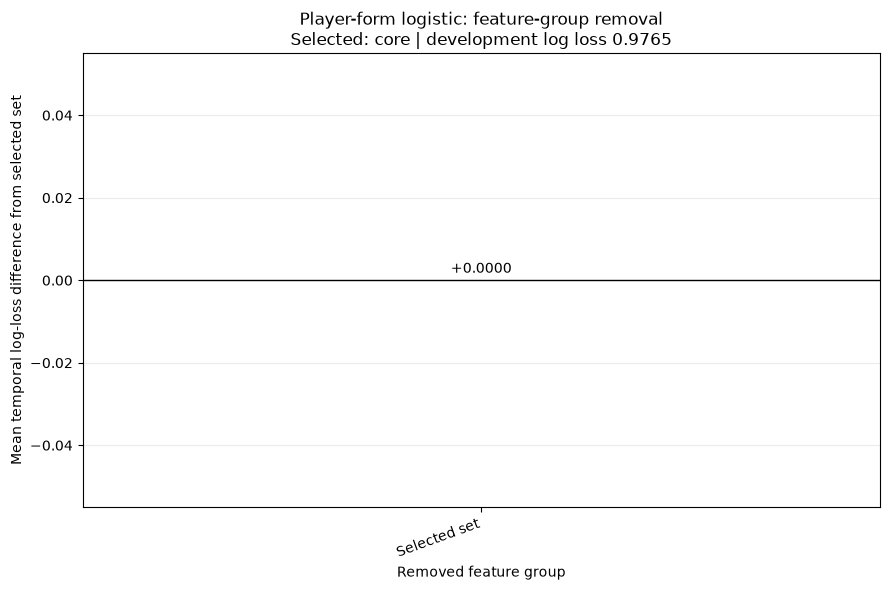

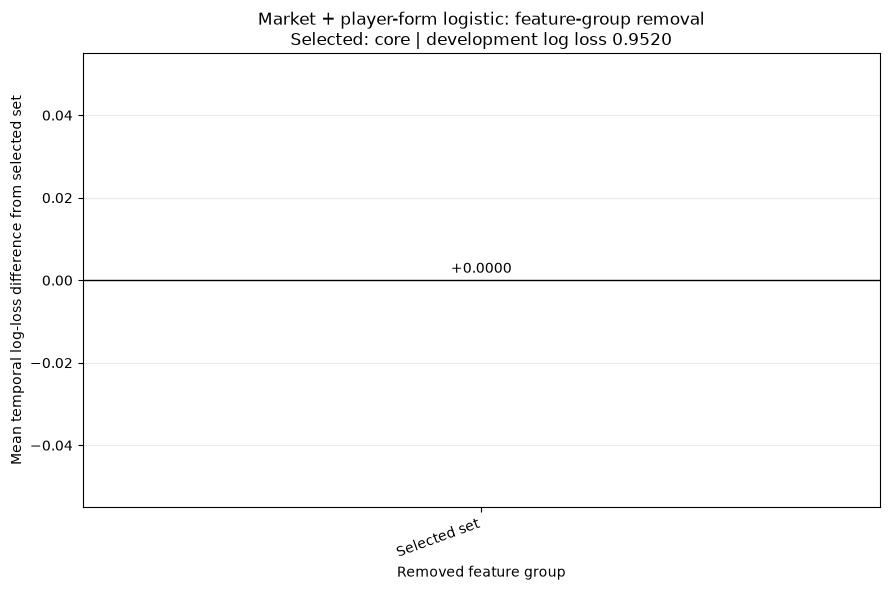

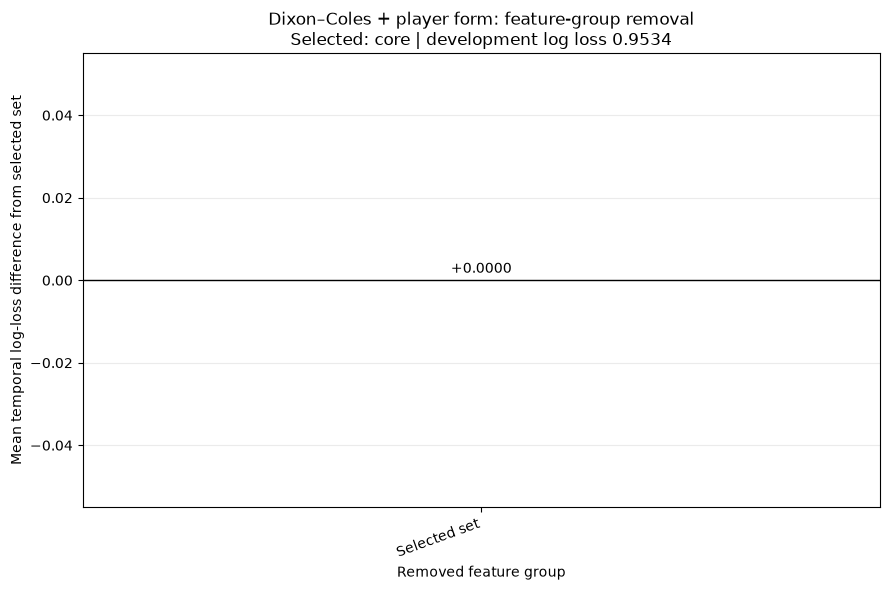

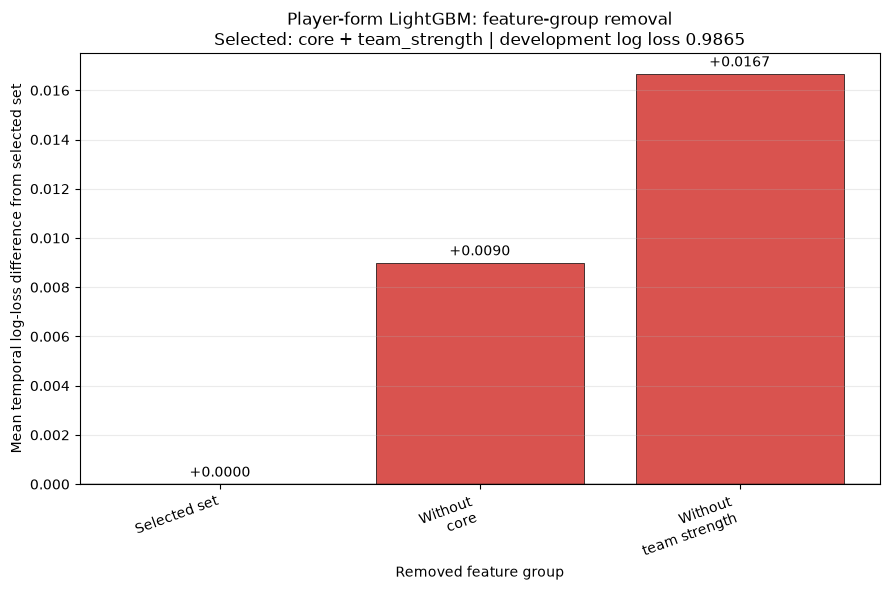

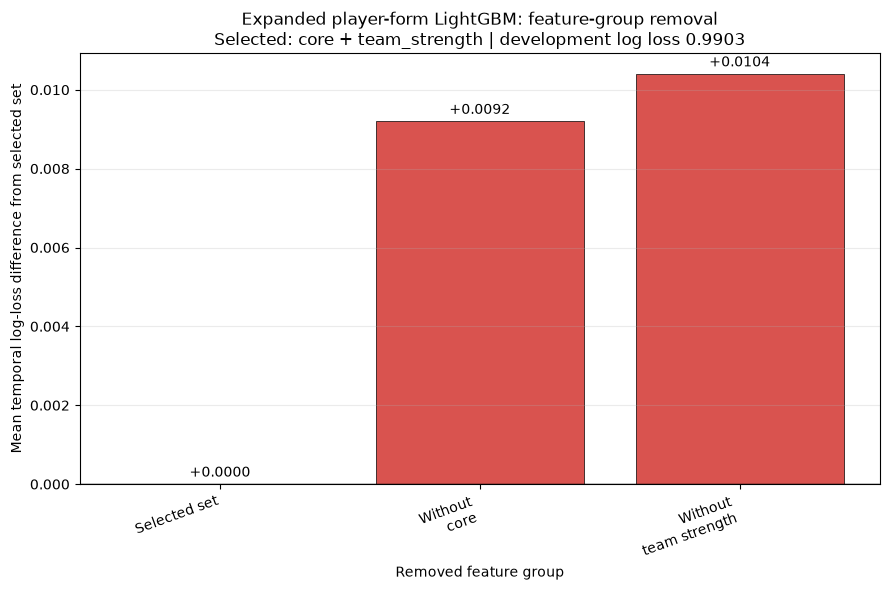

[WindowsPath('C:/Users/skous/Super-League-odds-research/scotland_research/visuals/feature_removal_help/player_form_logistic_feature_group_removal.png'),
 WindowsPath('C:/Users/skous/Super-League-odds-research/scotland_research/visuals/feature_removal_help/market_plus_player_form_feature_group_removal.png'),
 WindowsPath('C:/Users/skous/Super-League-odds-research/scotland_research/visuals/feature_removal_help/dixon_coles_player_form_feature_group_removal.png'),
 WindowsPath('C:/Users/skous/Super-League-odds-research/scotland_research/visuals/feature_removal_help/player_form_lightgbm_feature_group_removal.png'),
 WindowsPath('C:/Users/skous/Super-League-odds-research/scotland_research/visuals/feature_removal_help/expanded_player_form_lightgbm_feature_group_removal.png')]

In [10]:
def safe_filename(value: str) -> str:
    return re.sub(r"[^a-z0-9]+", "_", value.lower()).strip("_")

saved_images = []
plt.style.use("default")

for spec in MODEL_SPECS:
    model_rows = removal_summary[removal_summary["model"].eq(spec.name)].copy()
    model_rows["display_label"] = model_rows["removed_group"].map(
        lambda value: "Selected set" if value == "none" else f"Without\n{value.replace('_', ' ')}"
    )
    differences = model_rows["log_loss_difference_from_selected"]
    colors = [
        "#4472C4" if group == "none" else "#D9534F" if difference > 0 else "#5CB85C"
        for group, difference in zip(
            model_rows["removed_group"], differences, strict=True
        )
    ]

    fig, ax = plt.subplots(figsize=(max(9, len(model_rows) * 1.7), 6))
    bars = ax.bar(
        model_rows["display_label"],
        differences,
        color=colors,
        edgecolor="black",
        linewidth=0.5,
    )
    ax.axhline(0, color="black", linewidth=1)
    ax.bar_label(bars, labels=[f"{value:+.4f}" for value in differences], padding=3)
    selected_name = model_rows["selected_feature_set"].iloc[0]
    selected_loss = model_rows.loc[model_rows["removed_group"].eq("none"), "mean_log_loss"].iloc[0]
    ax.set_title(
        f"{spec.label}: feature-group removal\nSelected: {selected_name} | development log loss {selected_loss:.4f}"
    )
    ax.set_ylabel("Mean temporal log-loss difference from selected set")
    ax.set_xlabel("Removed feature group")
    ax.grid(axis="y", alpha=0.25)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()

    image_path = IMAGE_DIR / f"{safe_filename(spec.name)}_feature_group_removal.png"
    fig.savefig(image_path, dpi=300, bbox_inches="tight")
    saved_images.append(image_path)
    plt.show()

saved_images

In [ ]:
addition_folds.to_csv(OUTPUT_DIR / "feature_group_addition_folds.csv", index=False)
addition_summary.to_csv(OUTPUT_DIR / "feature_group_addition_summary.csv", index=False)
selected_feature_sets.to_csv(OUTPUT_DIR / "selected_feature_sets.csv", index=False)
removal_folds.to_csv(OUTPUT_DIR / "feature_group_removal_folds.csv", index=False)
removal_summary.to_csv(OUTPUT_DIR / "feature_group_removal_summary.csv", index=False)
dixon_coles_diagnostics = pd.concat(dixon_coles_diagnostic_frames, ignore_index=True) if dixon_coles_diagnostic_frames else pd.DataFrame()
dixon_coles_diagnostics.to_csv(OUTPUT_DIR / "dixon_coles_prediction_diagnostics.csv", index=False)

print(f"Saved tables to {OUTPUT_DIR}")
print(f"Saved {len(saved_images)} model-specific images to {IMAGE_DIR}")

## Interpretation checklist

- Prefer a smaller feature set when its mean log loss is within the declared tolerance of the minimum.
- Require a useful group to help across seasons, not only in the pooled average.
- Treat a negative removal difference as evidence that the group may add noise for that model.
- Do not compare the absolute performance of different model families until their own feature set and regularization have been tuned.
- Freeze the final feature-set rules before replication outside Scotland.